                        FINANCIAL ANALYSIS, PROBABILISTIC MODELING, AND STATISTICAL VALIDATION OF BIG TECH STOCKS  

Conducted by Alex Rosillo

[*********************100%***********************]  3 of 3 completed


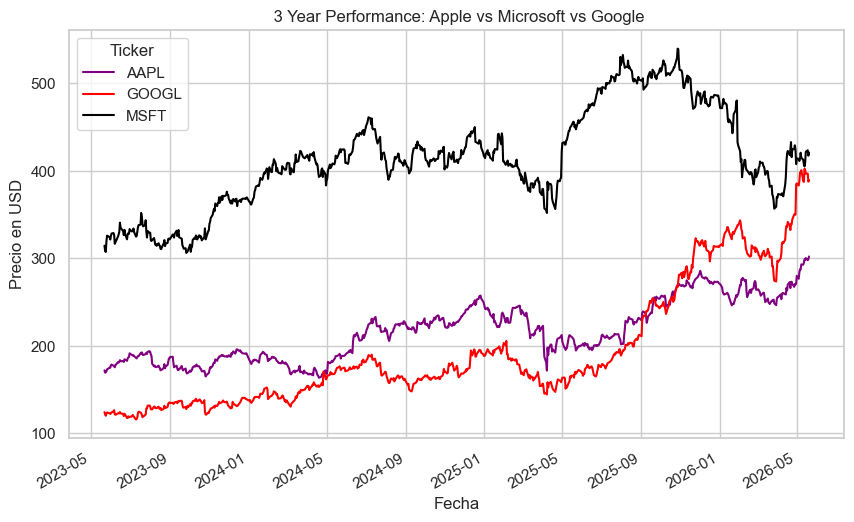

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
# Descargar datos de 3 años para Apple, Microsoft y Google
tickers = ["AAPL", "MSFT", "GOOGL"]
datos = yf.download(tickers, period="3y")

# Nos quedamos con el precio de cierre de todas ellas
precios_cierre = datos['Close']
mis_colores = ["purple", "red", "black"]

# Dibujamos graficas comparativas
precios_cierre.plot(figsize=(10, 6), color = mis_colores,  title=" 3 Year Performance: Apple vs Microsoft vs Google")
plt.xlabel("Fecha")
plt.ylabel("Precio en USD")
plt.grid(True) # Esto añade una cuadrícula de fondo para leer mejor los precios
plt.show()

In [8]:
import pandas as pd
import numpy as np

#Calculamos los retornos diarios (básicamente el como cambia el precio día a día en porcentaje)
retornos_diarios = precios_cierre.pct_change()

# Calculamos la Rentabilidad Total en estos 3 años
# Comparamos el último precio disponible con el primero
rentabilidad_total = ((precios_cierre.iloc[-1] - precios_cierre.iloc[0]) / precios_cierre.iloc[0]) * 100

#  Calculamos la Volatilidad Anualizada (Riesgo)
volatilidad = retornos_diarios.std() * np.sqrt(252) * 100

# Encontramos el peor día de cada acción
peor_dia = retornos_diarios.min() * 100

#  Juntamos todo en una tabla limpia para comparar
tabla_conclusiones = pd.DataFrame({
    'Total Return (%)': rentabilidad_total,
    'Annual Volatility (%)': volatilidad,
    'Worst Single Day (%)': peor_dia
})

# Mostrar el resultado final redondeado a 2 decimales
print("=== FINANCIAL METRICS (3 YEARS) ===")
print(tabla_conclusiones.round(2))

=== FINANCIAL METRICS (3 YEARS) ===
        Total Return (%)  Annual Volatility (%)  Worst Single Day (%)
Ticker                                                               
AAPL               75.74                  25.81                 -9.25
GOOGL             212.05                  29.62                 -9.51
MSFT               33.36                  23.62                 -9.99


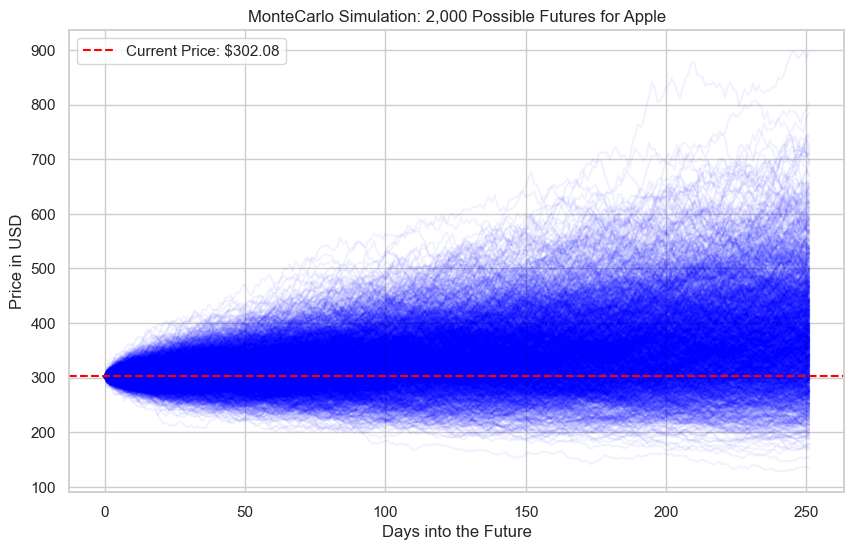

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Configuramos todo lo necesario
ACCION = 'AAPL'
DIAS_A_SIMULAR = 252  # 1 año completo de bolsa
NUM_SIMULACIONES = 2000  # Vamos a crear 2.000 futuros posibles

#  Extraemos la media y la volatilidad histórica diaria de esa acción
media_diaria = retornos_diarios[ACCION].mean()
volatilidad_diaria = retornos_diarios[ACCION].std()
precio_inicial = precios_cierre[ACCION].iloc[-1]

# Aplicamos una simulación de montecarlo
predicciones = np.zeros((DIAS_A_SIMULAR, NUM_SIMULACIONES))
predicciones[0] = precio_inicial

for t in range(1, DIAS_A_SIMULAR):
    # Generamos choques aleatorios basados en una distribución normal (Campana de Gauss)
    shocks = np.random.normal(media_diaria, volatilidad_diaria, NUM_SIMULACIONES)
    predicciones[t] = predicciones[t-1] * (1 + shocks)

plt.figure(figsize=(10, 6))
plt.plot(predicciones, color='blue', alpha=0.05)  # Líneas muy finitas y transparentes
plt.axhline(precio_inicial, color='red', linestyle='--', label=f'Current Price: ${precio_inicial:.2f}')
plt.title(f"MonteCarlo Simulation: 2,000 Possible Futures for Apple")
plt.xlabel("Days into the Future")
plt.ylabel("Price in USD")
plt.legend()
plt.grid(True)
plt.show()

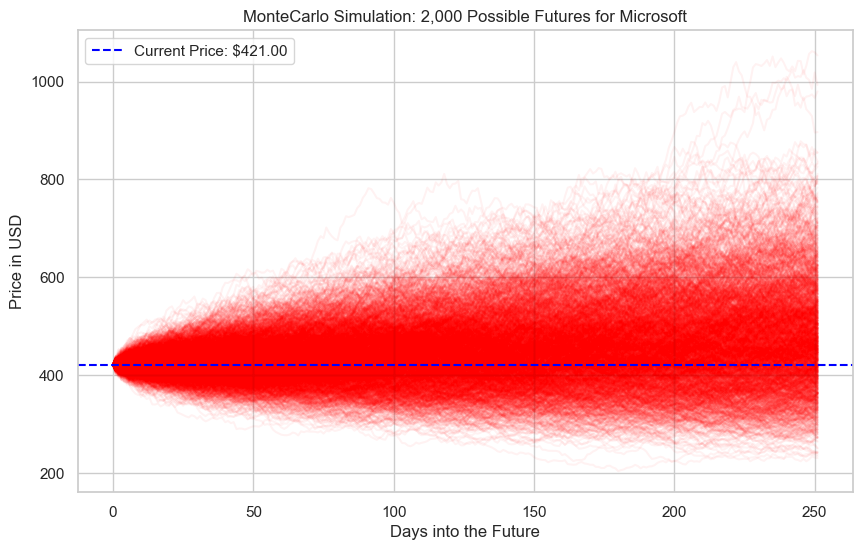

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Configuramos todo lo necesario
ACCION = 'MSFT' 
DIAS_A_SIMULAR = 252 
NUM_SIMULACIONES = 2000  

media_diaria = retornos_diarios[ACCION].mean()
volatilidad_diaria = retornos_diarios[ACCION].std()
precio_inicial = precios_cierre[ACCION].iloc[-1]

predicciones = np.zeros((DIAS_A_SIMULAR, NUM_SIMULACIONES))
predicciones[0] = precio_inicial

for t in range(1, DIAS_A_SIMULAR):
    # Generamos choques aleatorios basados en una distribución normal (Campana de Gauss)
    shocks = np.random.normal(media_diaria, volatilidad_diaria, NUM_SIMULACIONES)
    predicciones[t] = predicciones[t-1] * (1 + shocks)

plt.figure(figsize=(10, 6))
plt.plot(predicciones, color='red', alpha=0.05)  # Líneas muy finitas y transparentes
plt.axhline(precio_inicial, color='blue', linestyle='--', label=f'Current Price: ${precio_inicial:.2f}')
plt.title(f"MonteCarlo Simulation: 2,000 Possible Futures for Microsoft")
plt.xlabel("Days into the Future")
plt.ylabel("Price in USD")
plt.legend()
plt.grid(True)
plt.show()

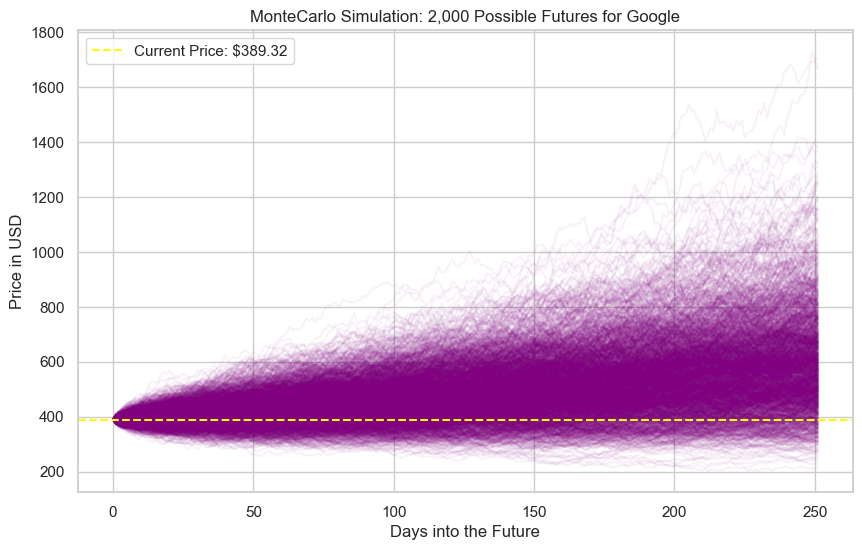

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Configuramos todo lo necesario
ACCION = 'GOOGL' 
DIAS_A_SIMULAR = 252  # 1 año completo de bolsa
NUM_SIMULACIONES = 2000  # Vamos a crear 2.000 futuros posibles

#  Extraemos la media y la volatilidad histórica diaria de esa acción
media_diaria = retornos_diarios[ACCION].mean()
volatilidad_diaria = retornos_diarios[ACCION].std()
precio_inicial = precios_cierre[ACCION].iloc[-1]

# Aplicamos una simulación de montecarlo
predicciones = np.zeros((DIAS_A_SIMULAR, NUM_SIMULACIONES))
predicciones[0] = precio_inicial

for t in range(1, DIAS_A_SIMULAR):
    # Generamos choques aleatorios basados en una distribución normal (Campana de Gauss)
    shocks = np.random.normal(media_diaria, volatilidad_diaria, NUM_SIMULACIONES)
    predicciones[t] = predicciones[t-1] * (1 + shocks)

plt.figure(figsize=(10, 6))
plt.plot(predicciones, color='purple', alpha=0.05)  # Líneas muy finitas y transparentes
plt.axhline(precio_inicial, color='yellow', linestyle='--', label=f'Current Price: ${precio_inicial:.2f}')
plt.title(f"MonteCarlo Simulation: 2,000 Possible Futures for Google")
plt.xlabel("Days into the Future")
plt.ylabel("Price in USD")
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  4 of 4 completed


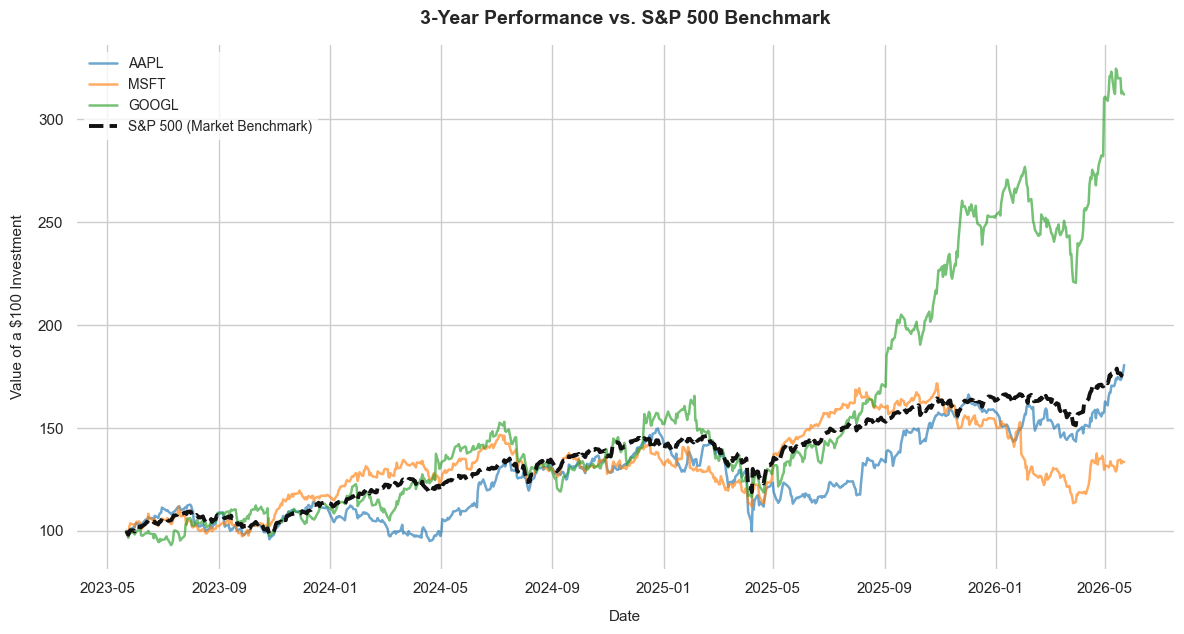

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme(style="whitegrid")
tickers_con_benchmark = ["AAPL", "MSFT", "GOOGL", "^GSPC"]
datos_completos = yf.download(tickers_con_benchmark, period="3y")['Close']
datos_completos = datos_completos.rename(columns={'^GSPC': 'S&P 500 (Market)'})
#  Normalizamos a Base 100
precios_normalizados = (datos_completos / datos_completos.iloc[0]) * 100
plt.figure(figsize=(12, 6.5)) 

colores_acciones = {'AAPL': '#1f77b4', 'MSFT': '#ff7f0e', 'GOOGL': '#2ca02c'}
for col in ['AAPL', 'MSFT', 'GOOGL']:
    plt.plot(precios_normalizados[col], label=f"{col}", color=colores_acciones[col], alpha=0.65, linewidth=1.8)

# El S&P 500 destaca por encima de todos
plt.plot(precios_normalizados['S&P 500 (Market)'], color='#111111', linewidth=2.8, linestyle='--', label='S&P 500 (Market Benchmark)')
plt.title("3-Year Performance vs. S&P 500 Benchmark", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=11, labelpad=10)
plt.ylabel("Value of a $100 Investment", fontsize=11, labelpad=10)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=10)

sns.despine(left=True, bottom=True)
plt.tight_layout() 
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import skew, kurtosis

# Calculamos los retornos diarios 
retornos = precios_cierre.pct_change().dropna()
resumen_stats = {}

for col in ['AAPL', 'MSFT', 'GOOGL']:
    resumen_stats[col] = {
        'Daily Mean (%)': retornos[col].mean() * 100,
        'Daily Volatility (%)': retornos[col].std() * 100,
        'Skewness (Asimetría)': skew(retornos[col]),
        'Kurtosis (Curtosis)': kurtosis(retornos[col]),
        'Minimum Daily Return (%)': retornos[col].min() * 100,
        'Maximum Daily Return (%)': retornos[col].max() * 100
    }

# Convertimos en un DataFrame limpio y transponer para que se lea mejor
tabla_estadistica = pd.DataFrame(resumen_stats).T

print("======================== STATISTICAL SUMMARY ========================")
print(tabla_estadistica.round(6))

======================== STATISTICAL SUMMARY ========================
       Daily Mean (%)  Daily Volatility (%)  Skewness (Asimetría)  \
AAPL         0.088218              1.626167              0.765481   
MSFT         0.049409              1.487716             -0.135157   
GOOGL        0.168962              1.866095              0.300174   

       Kurtosis (Curtosis)  Minimum Daily Return (%)  Maximum Daily Return (%)  
AAPL             12.854295                 -9.245606                 15.328842  
MSFT              6.697103                 -9.993146                 10.133694  
GOOGL             5.050876                 -9.509407                 10.224341  


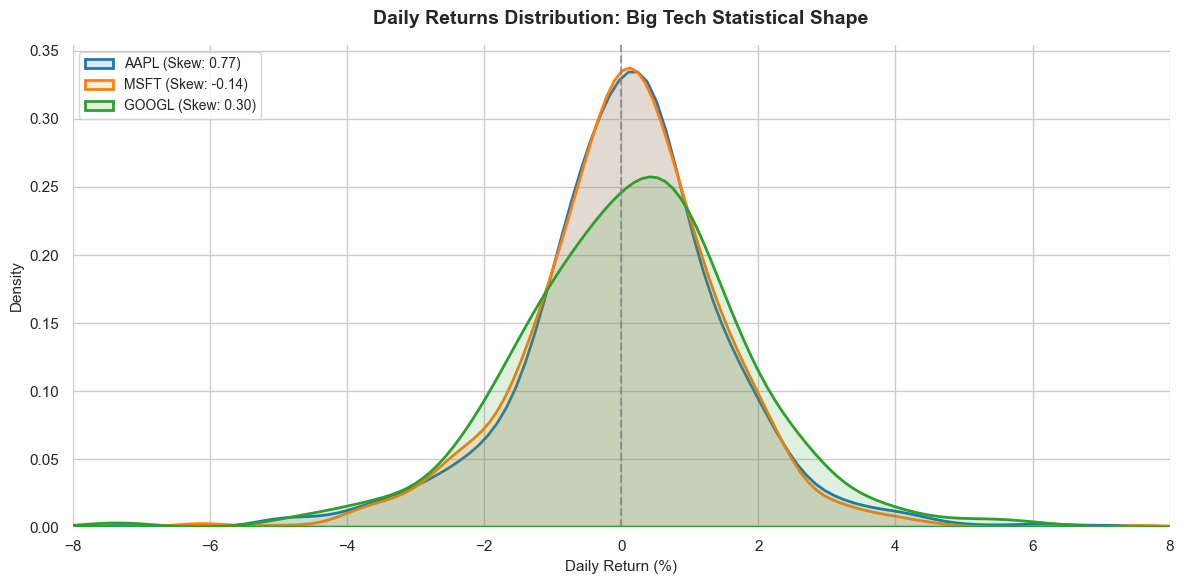

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
colores_acciones = {'AAPL': '#1f77b4', 'MSFT': '#ff7f0e', 'GOOGL': '#2ca02c'}

for col in ['AAPL', 'MSFT', 'GOOGL']:
    sns.kdeplot(
        retornos[col] * 100, 
        label=f"{col} (Skew: {tabla_estadistica.loc[col, 'Skewness (Asimetría)']:.2f})", 
        color=colores_acciones[col], 
        fill=True,
        alpha=0.15, 
        linewidth=2
    )

# Añadimos una línea vertical en 0% (el punto de equilibrio diario)
plt.axvline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
# Maquetamos el cout
plt.title("Daily Returns Distribution: Big Tech Statistical Shape", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Daily Return (%)", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.xlim(-8, 8) 
plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import shapiro, anderson
from statsmodels.stats.diagnostic import lilliefors

retornos = precios_cierre.pct_change().dropna()
resultados_tests = {}

for col in ['AAPL', 'MSFT', 'GOOGL']:
    # Test de Shapiro-Wilk
    stat_shapiro, p_shapiro = shapiro(retornos[col])
    # Test de Lilliefors (Kolmogorov-Smirnov modificado)
    stat_lillie, p_lillie = lilliefors(retornos[col])
    # Test de Anderson-Darling
    res_anderson = anderson(retornos[col], dist='norm')
    # Guardamos el estadístico y el valor crítico para el nivel del 5%
    stat_anderson = res_anderson.statistic
    critico_5pct = res_anderson.critical_values[2] # El índice 2 corresponde al 5%
    resultados_tests[col] = {
        'Shapiro p-value': p_shapiro,
        'Lilliefors p-value': p_lillie,
        'Anderson Stat': stat_anderson,
        'Anderson Crit (5%)': critico_5pct
    }


tabla_tests = pd.DataFrame(resultados_tests).T
print("============================ FORMAL NORMALITY TESTS =============================")
print(tabla_tests.round(6))

============================ FORMAL NORMALITY TESTS =============================
       Shapiro p-value  Lilliefors p-value  Anderson Stat  Anderson Crit (5%)
AAPL               0.0               0.001      11.408967               0.751
MSFT               0.0               0.001       6.084956               0.751
GOOGL              0.0               0.001       6.230210               0.751


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15472\390886883.py:18: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res_anderson = anderson(retornos[col], dist='norm')
